# MDC vNext -- Cross-Module Analysis & Synthesis (KAGGLE)

**5th notebook -- run last, after preprocess -> model -> drift-aware -> baselines.**
Ties together the outputs of all four prior notebooks into one place: raw dataset
patterns/timeline, how the data drifts over time, a single consolidated results
table, and the drift-aware findings summary -- everything a thesis Results chapter
needs, generated from one file instead of scattered across four.

**Inputs (attach all four via '+ Add Data', same pattern as every other notebook
in this track):**

| Zip (produced by) | Files this notebook reads |
|---|---|
| `windows_vnext_processed.zip` (preprocess) | `windows_vnext.npz`, `drift_baseline_vnext.npz`, `manifest_vnext.json` |
| `model_vnext_runs.zip` (model) | `metrics_vnext.json`, `metrics_ablation_vnext.json`, `eval_multiclass.json` |
| `drift_aware_outputs.zip` (drift-aware) | `drift_aware_log.csv` (or `.json`), `adaptive_report.json`, `matched_policy_comparison.json`, `finetune_report.json`, `baseline_comparison.json`, `freeze_manifest_v2.json` |
| `deep_baseline_comparison.zip` (baselines) | `deep_baseline_comparison.json` |

**Every input is optional** -- if a zip isn't attached yet, the corresponding
section prints a clear "not found" note and produces a partial result instead of
crashing, the same graceful-degradation pattern used in `mdc_baselines_kaggle.ipynb`.

**Known scope limit:** `X_train` (benign-only) has no saved timestamps or container
IDs in `windows_vnext.npz` -- only `val`/`test` carry `ts_*`/`c_*`. So the timeline
analysis below covers val+test only; there is no "normal behavior over time"
baseline from the training split, because that data was never captured.


## 0. Environment

In [4]:
import sys, os, subprocess
_IN_KAGGLE = os.path.exists('/kaggle/working')
if _IN_KAGGLE:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'pandas', 'numpy', 'matplotlib'], check=False)
print(f'In Kaggle: {_IN_KAGGLE}')


In Kaggle: True


## 1. Configuration

In [5]:
from __future__ import annotations
import json
from pathlib import Path
import numpy as np
import pandas as pd

VERSION = 'vnext'

ANALYSIS_DIR = Path('/kaggle/working/analysis') if _IN_KAGGLE else Path('../outputs/vNEXT_test/analysis')
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = ANALYSIS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_TIME_BUCKETS = 20   # chronological buckets for the PSI-over-time trend

print('Config loaded')
print(f'  ANALYSIS_DIR : {ANALYSIS_DIR}')
print(f'  FIG_DIR      : {FIG_DIR}')


Config loaded
  ANALYSIS_DIR : /kaggle/working/analysis
  FIG_DIR      : /kaggle/working/analysis/figures


## 2. Load inputs from all four zips (each optional)

In [6]:
# --- Kaggle IO helpers (self-contained -- no Drive, no Colab) ---
import os, sys, glob, shutil, zipfile, base64
from pathlib import Path

_IN_KAGGLE = os.path.exists('/kaggle/working')

KAGGLE_WORKING = Path('/kaggle/working')
KAGGLE_INPUT   = Path('/kaggle/input')

def kaggle_find(name, extra_dirs=()):
    """Search /kaggle/input/**, /kaggle/working/**, and extra_dirs for a file by
    name. There is no live shared Drive on Kaggle -- to hand a file from one
    notebook to the next, either (a) attach the producing notebook's own
    output via '+ Add Data > Your Notebooks' (no manual zip needed), or
    (b) download this notebook's output zip and upload it as a new Kaggle
    Dataset, then attach that dataset. Either way it shows up under
    /kaggle/input/<name>/ and this function finds it there."""
    roots = [KAGGLE_INPUT, KAGGLE_WORKING, *[Path(d) for d in extra_dirs]]
    for root in roots:
        if not root.is_dir():
            continue
        hits = sorted(glob.glob(str(root / '**' / name), recursive=True))
        if hits:
            return Path(hits[0])
    return None

def kaggle_upload_fallback(name, dest_dir):
    """Best-effort interactive upload widget for a live session. Not available
    during a headless 'Save & Run All' commit (no UI) -- attach the file as
    input data instead in that case."""
    try:
        import ipywidgets as widgets
        from IPython.display import display
        uploader = widgets.FileUpload(accept='', multiple=False)
        display(uploader)
        print(f'Upload {name} with the widget above, then re-run this cell.')
        if uploader.value:
            item = list(uploader.value.values())[0]
            content = item['content'] if isinstance(item, dict) else item.content
            dest = Path(dest_dir) / name
            dest.parent.mkdir(parents=True, exist_ok=True)
            dest.write_bytes(bytes(content))
            print(f'Saved -> {dest}')
            return dest
    except Exception as e:
        print(f'Interactive upload unavailable ({e}).')
    return None

def zip_and_offer_download(src_dir, zip_name, max_auto_mb=25):
    """Zip src_dir into /kaggle/working/{zip_name}.zip and try to trigger a
    browser download automatically. Only fires in a live, actively-open
    browser tab (not during headless 'Save & Run All') -- Kaggle's own Output
    tab (right sidebar) always lists this zip for manual download regardless
    of whether the auto-download trick actually fires in your browser."""
    src_dir = Path(src_dir)
    zip_base = KAGGLE_WORKING / zip_name
    zip_path = zip_base.with_suffix('.zip')
    if zip_path.exists():
        zip_path.unlink()
    shutil.make_archive(str(zip_base), 'zip', root_dir=src_dir)
    size_mb = zip_path.stat().st_size / 1024 / 1024
    print(f'Zipped -> {zip_path}  ({size_mb:.1f} MB)')
    if size_mb <= max_auto_mb:
        try:
            from IPython.display import HTML, display
            b64 = base64.b64encode(zip_path.read_bytes()).decode()
            html = (
                f'<a id="dl_{zip_name}" download="{zip_path.name}" '
                f'href="data:application/zip;base64,{b64}"></a>'
                f'<script>document.getElementById("dl_{zip_name}").click();</script>'
            )
            display(HTML(html))
            print('Auto-download triggered (only works if this tab is actively open --')
            print('if nothing happened, use the Output tab on the right instead).')
        except Exception as e:
            print(f'Auto-download trick failed ({e}) -- use the Output tab instead.')
    else:
        print(f'{size_mb:.1f} MB exceeds the {max_auto_mb} MB auto-download guard -- '
              'skipping the browser trick to avoid bloating notebook output.')
        print('Get it from the Output tab (right sidebar) after Save Version instead.')
    return zip_path

print(f'Kaggle IO ready. In Kaggle: {_IN_KAGGLE}')

def load_json(name):
    p = kaggle_find(name)
    if p is None:
        print(f'  NOT FOUND: {name}')
        return None
    print(f'  found {name} -> {p}')
    return json.loads(p.read_text())

def load_path(name):
    p = kaggle_find(name)
    if p is None:
        print(f'  NOT FOUND: {name}')
        return None
    print(f'  found {name} -> {p}')
    return p

print('--- preprocess zip ---')
windows_npz_path = load_path('windows_vnext.npz')
drift_baseline_path = load_path('drift_baseline_vnext.npz')
manifest = load_json('manifest_vnext.json')

print('--- model zip ---')
metrics_vnext = load_json('metrics_vnext.json')
metrics_ablation = load_json('metrics_ablation_vnext.json')
eval_multiclass = load_json('eval_multiclass.json')

print('--- drift-aware zip ---')
drift_log_path = load_path('drift_aware_log.csv') or load_path('drift_aware_log.json')
adaptive_report = load_json('adaptive_report.json')
matched_policy = load_json('matched_policy_comparison.json')
finetune_report = load_json('finetune_report.json')
if_baseline = load_json('baseline_comparison.json')
freeze_manifest = load_json('freeze_manifest_v2.json')

print('--- baselines zip ---')
deep_baseline = load_json('deep_baseline_comparison.json')

print()
print('Summary of what was found:')
_inputs = {
    'windows_vnext.npz': windows_npz_path, 'drift_baseline_vnext.npz': drift_baseline_path,
    'manifest_vnext.json': manifest, 'metrics_vnext.json': metrics_vnext,
    'metrics_ablation_vnext.json': metrics_ablation, 'eval_multiclass.json': eval_multiclass,
    'drift_aware_log': drift_log_path, 'adaptive_report.json': adaptive_report,
    'matched_policy_comparison.json': matched_policy, 'finetune_report.json': finetune_report,
    'baseline_comparison.json (IF)': if_baseline, 'freeze_manifest_v2.json': freeze_manifest,
    'deep_baseline_comparison.json': deep_baseline,
}
for name, val in _inputs.items():
    print(f'  [{"OK " if val is not None else "MISSING"}] {name}')


Kaggle IO ready. In Kaggle: True
--- preprocess zip ---
  found windows_vnext.npz -> /kaggle/input/datasets/arurankirupanatha/windows-vnext-processed-2/windows_vnext.npz
  found drift_baseline_vnext.npz -> /kaggle/input/datasets/arurankirupanatha/windows-vnext-processed-2/drift_baseline_vnext.npz
  found manifest_vnext.json -> /kaggle/input/datasets/arurankirupanatha/windows-vnext-processed-2/manifest_vnext.json
--- model zip ---
  found metrics_vnext.json -> /kaggle/input/datasets/arurankirupanatha/model-vnext-runs-1/metrics_vnext.json
  NOT FOUND: metrics_ablation_vnext.json
  NOT FOUND: eval_multiclass.json
--- drift-aware zip ---
  found drift_aware_log.csv -> /kaggle/input/datasets/arurankirupanatha/drift-aware-outputs-2/drift_aware_log.csv
  found adaptive_report.json -> /kaggle/input/datasets/arurankirupanatha/drift-aware-outputs-2/adaptive_report.json
  found matched_policy_comparison.json -> /kaggle/input/datasets/arurankirupanatha/drift-aware-outputs-2/matched_policy_comparis

## 3. Dataset timeline analysis (val + test only -- see scope note above)

Builds one dataframe from `windows_vnext.npz`'s `ts_val`/`ts_test`, `c_val`/`c_test`,
`y_val`/`y_test`, and `y_val_multiclass`/`y_test_multiclass`, sorted chronologically.
This is the direct answer to "how does the dataset change over time" -- real
per-window timestamps, not a proxy ordering.

Timeline windows (val+test): 10306
Span: 2023-03-19 12:51:15 -> 2024-05-07 18:40:45
Containers: ['10.16.0.4', '10.16.0.5', '10.16.0.6', '10.16.0.9', '100.64.0.2']


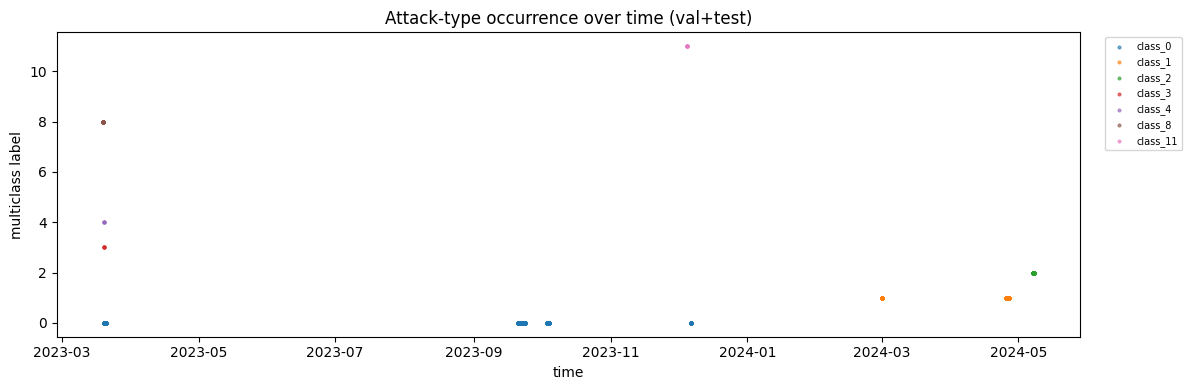

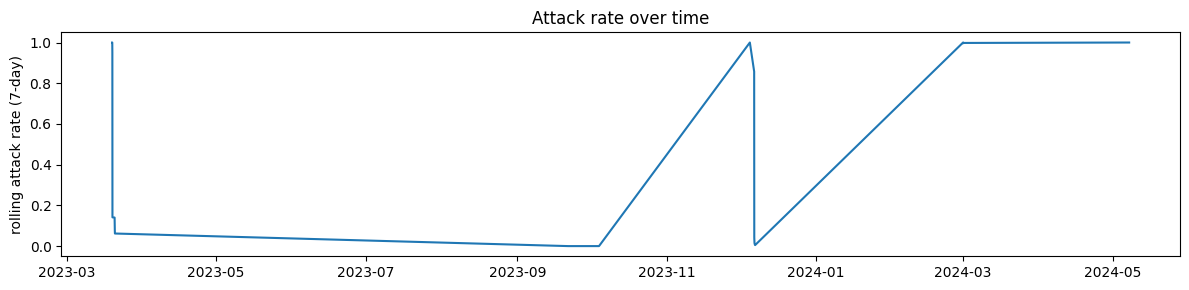

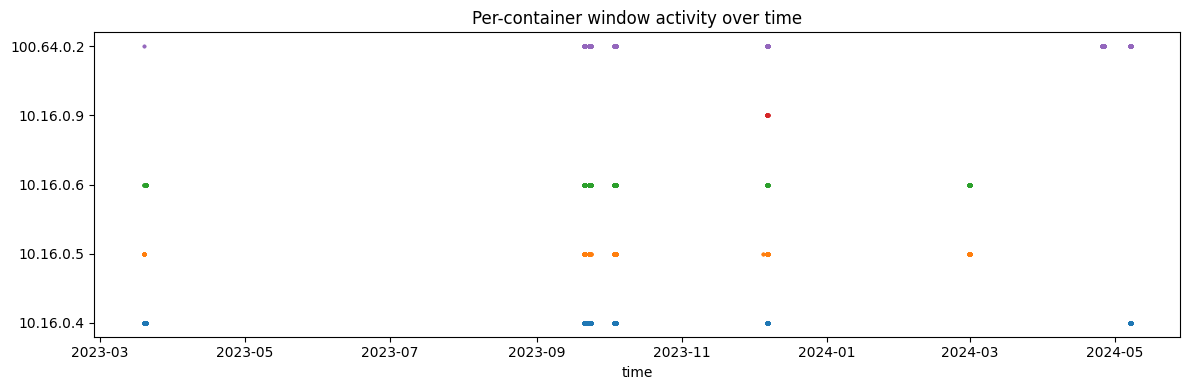

Saved -> /kaggle/working/analysis/timeline_val_test.csv


In [7]:
import matplotlib.pyplot as plt

timeline_df = None
if windows_npz_path is not None:
    z = np.load(windows_npz_path, allow_pickle=True)
    _ts = np.concatenate([z['ts_val'], z['ts_test']])
    _c  = np.concatenate([z['c_val'].astype(str), z['c_test'].astype(str)])
    _y  = np.concatenate([z['y_val'], z['y_test']])
    _has_mc = 'y_val_multiclass' in z.files and 'y_test_multiclass' in z.files
    _ymc = (np.concatenate([z['y_val_multiclass'], z['y_test_multiclass']])
            if _has_mc else np.full_like(_y, -1))
    timeline_df = pd.DataFrame({
        'ts': _ts, 'datetime': pd.to_datetime(_ts, unit='s'),
        'container': _c, 'label': _y, 'label_multiclass': _ymc,
    }).sort_values('ts').reset_index(drop=True)
    z.close()

    print(f'Timeline windows (val+test): {len(timeline_df)}')
    print(f'Span: {timeline_df["datetime"].min()} -> {timeline_df["datetime"].max()}')
    print(f'Containers: {sorted(timeline_df["container"].unique().tolist())}')

    # --- attack-type distribution over time ---
    label_names = (eval_multiclass or {}).get('label_names', {}) if eval_multiclass else {}
    timeline_df['label_name'] = timeline_df['label_multiclass'].astype(str).map(
        lambda k: label_names.get(k, k))

    fig, ax = plt.subplots(figsize=(12, 4))
    for lbl, grp in timeline_df.groupby('label_multiclass'):
        name = label_names.get(str(lbl), f'class_{lbl}')
        ax.scatter(grp['datetime'], [lbl] * len(grp), s=4, label=name, alpha=0.6)
    ax.set_xlabel('time'); ax.set_ylabel('multiclass label')
    ax.set_title('Attack-type occurrence over time (val+test)')
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'timeline_attack_types.png', dpi=200)
    plt.show()

    # --- rolling attack rate over time ---
    roll = timeline_df.set_index('datetime')['label'].rolling('7D', min_periods=1).mean()
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(roll.index, roll.values)
    ax.set_ylabel('rolling attack rate (7-day)'); ax.set_title('Attack rate over time')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'timeline_attack_rate.png', dpi=200)
    plt.show()

    # --- per-container activity over time ---
    fig, ax = plt.subplots(figsize=(12, 4))
    for cnt, grp in timeline_df.groupby('container'):
        ax.scatter(grp['datetime'], [cnt] * len(grp), s=3, alpha=0.5)
    ax.set_xlabel('time'); ax.set_title('Per-container window activity over time')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'timeline_containers.png', dpi=200)
    plt.show()

    timeline_df.to_csv(ANALYSIS_DIR / 'timeline_val_test.csv', index=False)
    print(f'Saved -> {ANALYSIS_DIR / "timeline_val_test.csv"}')
else:
    print('windows_vnext.npz not available -- skipping dataset timeline section.')


## 4. Feature drift over time -- computed directly from the dataset

Independent of drift-aware's own simulated stream: buckets val+test windows
chronologically (by real `ts`) and computes PSI of each bucket against the
benign-train baseline (`drift_baseline_vnext.npz`), using the same PSI formula
`mdc_drift_aware` itself uses (quantile-binned, +1 Laplace smoothing). This gives
a direct, from-raw-data drift signal to cross-check against drift-aware's own
trace in the next section.

 bucket      datetime_start  n_windows  mean_psi  frac_features_major_shift
      0 2023-03-19 12:51:15        515  0.821408                   0.693252
      1 2023-03-20 15:22:00        515  0.189712                   0.325153
      2 2023-09-21 01:07:00        515  0.361307                   0.607362
      3 2023-09-21 07:03:00        516  0.734993                   0.797546
      4 2023-09-21 13:49:00        515  1.274561                   0.822086
      5 2023-09-22 19:43:30        515  0.526430                   0.699387
      6 2023-09-23 01:54:00        516  0.168513                   0.220859
      7 2023-09-23 12:26:00        515  0.319208                   0.631902
      8 2023-10-03 14:35:15        515  0.467850                   0.705521
      9 2023-10-03 21:37:45        516  0.187291                   0.306748
     10 2023-10-04 07:33:00        515  0.482436                   0.588957
     11 2023-12-06 20:34:00        515  0.436194                   0.552147
     12 2023

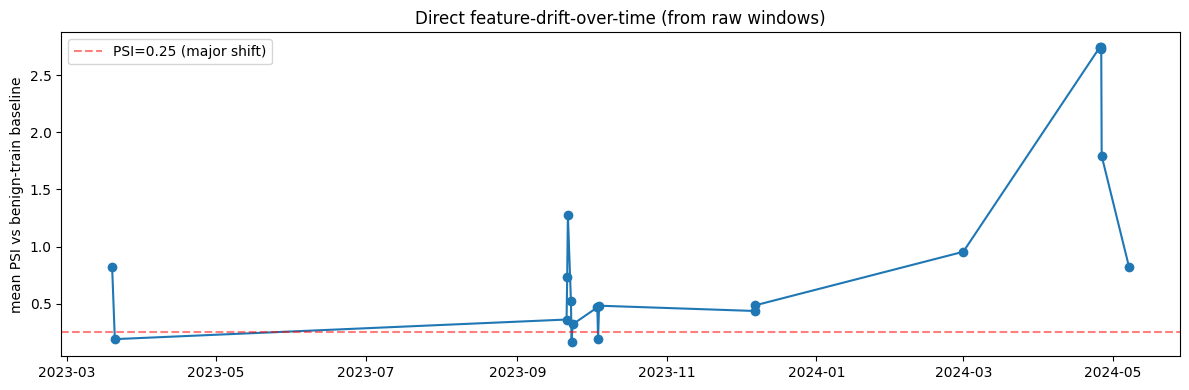

Saved -> /kaggle/working/analysis/psi_over_time_direct.csv


In [8]:
def psi_for_rows(flat_rows, drift_baseline):
    q_base = drift_baseline['q']
    F_ = flat_rows.shape[1]
    psis = np.zeros(F_, dtype=np.float32)
    for j in range(F_):
        edges = np.unique(q_base[:, j])
        if len(edges) < 3:
            continue
        edges = edges.copy(); edges[0] = -np.inf; edges[-1] = np.inf
        base_hist, _ = np.histogram(q_base[:, j], bins=edges)
        curr_hist, _ = np.histogram(flat_rows[:, j], bins=edges)
        base_p = (base_hist + 1) / (base_hist.sum() + len(edges) - 1)
        curr_p = (curr_hist + 1) / (curr_hist.sum() + len(edges) - 1)
        psis[j] = float(np.sum((curr_p - base_p) * np.log(curr_p / base_p)))
    return psis

psi_trend_df = None
if windows_npz_path is not None and drift_baseline_path is not None and timeline_df is not None:
    z = np.load(windows_npz_path, allow_pickle=True)
    X_all = np.concatenate([z['X_val'], z['X_test']], axis=0)
    ts_all = np.concatenate([z['ts_val'], z['ts_test']])
    z.close()

    order = np.argsort(ts_all, kind='stable')
    X_ord = X_all[order]
    ts_ord = timeline_df['ts'].to_numpy()  # already sorted the same way (built from the same ts_all)

    drift_z = np.load(drift_baseline_path, allow_pickle=True)
    drift_baseline = {'q': drift_z['q'], 'feat_names': drift_z['feat_names']}

    bucket_edges = np.linspace(0, len(X_ord), N_TIME_BUCKETS + 1).astype(int)
    rows = []
    for i in range(N_TIME_BUCKETS):
        lo, hi = bucket_edges[i], bucket_edges[i + 1]
        if hi <= lo:
            continue
        chunk = X_ord[lo:hi].reshape(-1, X_ord.shape[-1])
        psis = psi_for_rows(chunk, drift_baseline)
        rows.append({
            'bucket': i,
            'ts_start': int(ts_ord[lo]), 'ts_end': int(ts_ord[hi - 1]),
            'n_windows': hi - lo,
            'mean_psi': float(np.mean(psis)),
            'max_psi': float(np.max(psis)),
            'frac_features_major_shift': float(np.mean(psis > 0.25)),
        })
    psi_trend_df = pd.DataFrame(rows)
    psi_trend_df['datetime_start'] = pd.to_datetime(psi_trend_df['ts_start'], unit='s')

    print(psi_trend_df[['bucket', 'datetime_start', 'n_windows', 'mean_psi',
                         'frac_features_major_shift']].to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(psi_trend_df['datetime_start'], psi_trend_df['mean_psi'], marker='o')
    ax.axhline(0.25, color='r', ls='--', alpha=0.5, label='PSI=0.25 (major shift)')
    ax.set_ylabel('mean PSI vs benign-train baseline'); ax.set_title('Direct feature-drift-over-time (from raw windows)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'psi_over_time_direct.png', dpi=200)
    plt.show()

    psi_trend_df.to_csv(ANALYSIS_DIR / 'psi_over_time_direct.csv', index=False)
    print(f'Saved -> {ANALYSIS_DIR / "psi_over_time_direct.csv"}')
else:
    print('Need windows_vnext.npz + drift_baseline_vnext.npz -- skipping direct PSI section.')


## 5. Drift-aware's own simulated-stream trace (cross-check vs section 4)

Re-loads `drift_aware_log` (score / threshold / alert / PSI per simulated-stream
step) and plots it alongside the direct PSI computed above. If the two disagree
noticeably, that's worth noting -- they use different methods (drift-aware's PSI
is windowed over the last 100 steps of its own simulation; section 4's is
bucketed directly from real timestamps).

drift_aware_log: 5153 steps, columns=['t', 'score', 'threshold_raw', 'threshold_alert', 'alert', 'label', 'mean_psi', 'finetuned', 'stream_ordering']


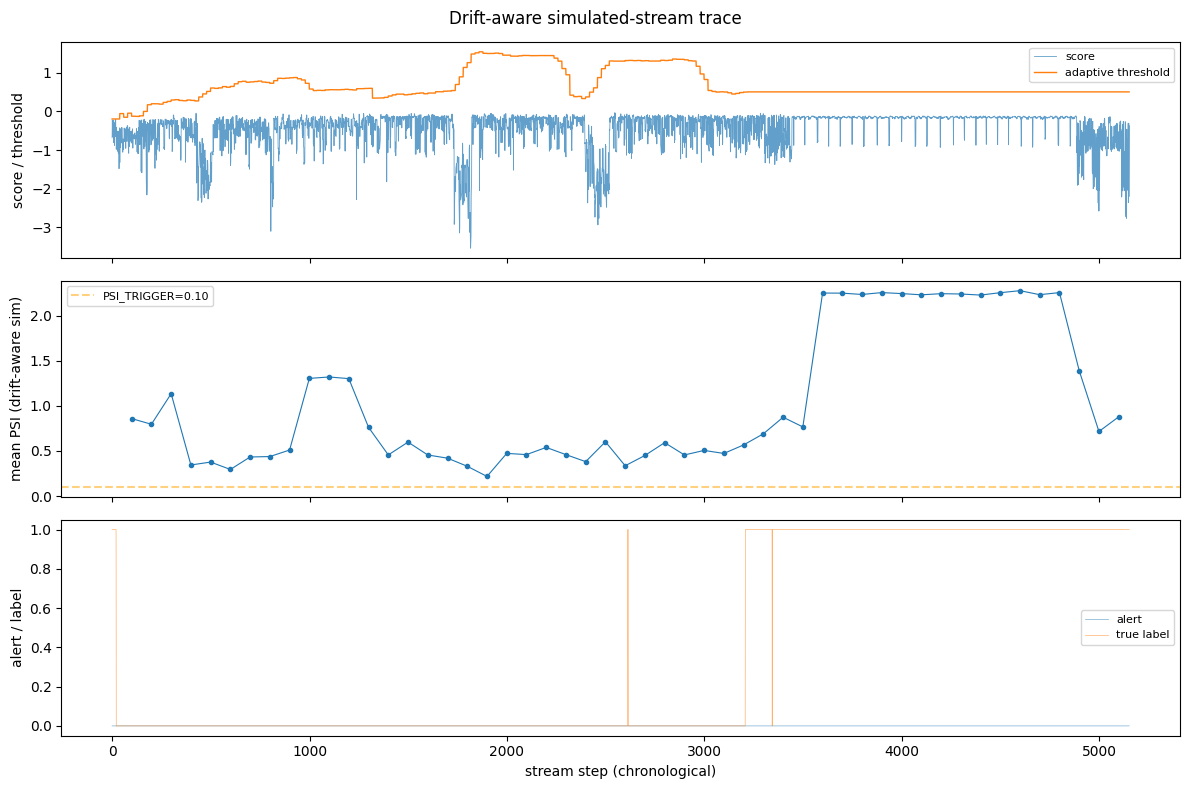

In [9]:
drift_log_df = None
if drift_log_path is not None:
    if drift_log_path.suffix == '.csv':
        drift_log_df = pd.read_csv(drift_log_path)
    else:
        drift_log_df = pd.DataFrame(json.loads(drift_log_path.read_text()))
    print(f'drift_aware_log: {len(drift_log_df)} steps, columns={list(drift_log_df.columns)}')

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(drift_log_df['t'], drift_log_df['score'], lw=0.6, alpha=0.7, label='score')
    if 'threshold_raw' in drift_log_df.columns:
        axes[0].plot(drift_log_df['t'], drift_log_df['threshold_raw'], lw=1.0, label='adaptive threshold')
    axes[0].set_ylabel('score / threshold'); axes[0].legend(fontsize=8)

    if 'mean_psi' in drift_log_df.columns:
        _psi = drift_log_df['mean_psi'].dropna()
        axes[1].plot(_psi.index, _psi.values, marker='.', lw=0.8)
        axes[1].axhline(0.10, color='orange', ls='--', alpha=0.5, label='PSI_TRIGGER=0.10')
        axes[1].set_ylabel('mean PSI (drift-aware sim)'); axes[1].legend(fontsize=8)

    if 'alert' in drift_log_df.columns:
        axes[2].plot(drift_log_df['t'], drift_log_df['alert'], lw=0.5, alpha=0.6, label='alert')
    if 'label' in drift_log_df.columns:
        axes[2].plot(drift_log_df['t'], drift_log_df['label'], lw=0.5, alpha=0.6, label='true label')
    axes[2].set_ylabel('alert / label'); axes[2].set_xlabel('stream step (chronological)')
    axes[2].legend(fontsize=8)

    plt.suptitle('Drift-aware simulated-stream trace')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'drift_aware_trace.png', dpi=200)
    plt.show()
else:
    print('drift_aware_log not available -- skipping drift-aware trace section.')


## 6. Unified results table

Merges `metrics_vnext.json` (default / multi-seed / HPO), `metrics_ablation_vnext.json`
(no_contractive / no_early_stop), and `deep_baseline_comparison.json`'s own
`comparison_table` (which already includes Isolation Forest + Dense AE + vNext
default/HPO) into one table -- the single reference your Results section needs.

In [10]:
rows = []

if metrics_vnext is not None:
    _def = metrics_vnext.get('test_default', {}).get('f1_optimal', {})
    if _def:
        rows.append({'config': 'vNext default', 'roc_auc': _def.get('roc_auc'),
                      'f1': _def.get('f1'), 'mcc': _def.get('mcc'), 'source': 'metrics_vnext.json'})
    _ms = metrics_vnext.get('multi_seed', {})
    if _ms:
        rows.append({'config': 'vNext multi-seed (mean)',
                      'roc_auc': _ms.get('roc_auc', {}).get('mean'),
                      'f1': _ms.get('f1', {}).get('mean'), 'mcc': _ms.get('mcc', {}).get('mean'),
                      'source': 'metrics_vnext.json'})
    _hpo = metrics_vnext.get('test_hpo', {})
    if _hpo:
        rows.append({'config': 'vNext HPO best', 'roc_auc': _hpo.get('roc_auc'),
                      'f1': _hpo.get('f1'), 'mcc': _hpo.get('mcc'), 'source': 'metrics_vnext.json'})

if metrics_ablation is not None:
    for name, payload in metrics_ablation.items():
        t = payload.get('test', {})
        rows.append({'config': f'ablation: {name}', 'roc_auc': t.get('roc_auc'),
                      'f1': t.get('f1'), 'mcc': t.get('mcc'), 'source': 'metrics_ablation_vnext.json'})

if deep_baseline is not None:
    for r in deep_baseline.get('comparison_table', []):
        rows.append({'config': r.get('config'), 'roc_auc': r.get('roc_auc'),
                      'f1': r.get('f1'), 'mcc': r.get('mcc'), 'source': r.get('source', 'deep_baseline_comparison.json')})
elif if_baseline is not None:
    _if = if_baseline.get('isolation_forest_mean_max', {}).get('metrics', {})
    if _if:
        rows.append({'config': 'Isolation Forest', 'roc_auc': _if.get('roc_auc'),
                      'f1': _if.get('f1'), 'mcc': _if.get('mcc'), 'source': 'baseline_comparison.json'})

results_df = pd.DataFrame(rows)
print('=== Unified results table ===')
if len(results_df):
    print(results_df.to_string(index=False))
    results_df.to_csv(ANALYSIS_DIR / 'unified_results_table.csv', index=False)
    print(f'\nSaved -> {ANALYSIS_DIR / "unified_results_table.csv"}')
else:
    print('No inputs available for the results table -- attach at least one of '
          'metrics_vnext.json / metrics_ablation_vnext.json / deep_baseline_comparison.json.')


=== Unified results table ===
                          config  roc_auc       f1      mcc                source
                   vNext default 0.688916 0.660342 0.423353    metrics_vnext.json
         vNext multi-seed (mean) 0.726114 0.725787 0.559244    metrics_vnext.json
                  vNext HPO best 0.844607 0.803018 0.708034    metrics_vnext.json
        Dense AE (this notebook) 0.662446 0.626228 0.343583   mdc_baselines.ipynb
Isolation Forest (mean_max pool) 0.674149 0.710387 0.503425 mdc_drift_aware.ipynb
  vNext default (Transformer AE) 0.688916 0.660342 0.423353 mdc_model_vNext.ipynb
 vNext HPO best (Transformer AE) 0.844607 0.803018 0.708034 mdc_model_vNext.ipynb

Saved -> /kaggle/working/analysis/unified_results_table.csv


## 7. Drift-aware findings summary

One block pulling `claim_ok`, fine-tune source/delta, and freeze status from
`matched_policy_comparison.json` / `finetune_report.json` / `freeze_manifest_v2.json`
-- paragraph-ready for the thesis Discussion section.

In [11]:
findings = {}

if matched_policy is not None:
    findings['adaptive_threshold_claim_ok'] = matched_policy.get('claim_adaptive_improves_without_recall_loss')
    findings['adaptive_threshold_interpretation'] = matched_policy.get('interpretation')

if finetune_report is not None:
    findings['finetune_source'] = finetune_report.get('finetune_benign_source')
    findings['finetune_auc_before'] = finetune_report.get('auc_before')
    findings['finetune_auc_after'] = finetune_report.get('auc_after')
    findings['finetune_auc_delta'] = finetune_report.get('auc_delta')
    findings['finetune_interpretation'] = finetune_report.get('interpretation')

if freeze_manifest is not None:
    findings['freeze_ready'] = freeze_manifest.get('freeze_ready')
    findings['ordering_mode'] = freeze_manifest.get('gates', {}).get('ordering_mode')

if adaptive_report is not None:
    findings['stream_ordering'] = adaptive_report.get('stream_ordering', {}).get('ordering_mode')

print('=== Drift-aware findings summary ===')
for k, v in findings.items():
    print(f'  {k}: {v}')

(ANALYSIS_DIR / 'drift_aware_findings_summary.json').write_text(json.dumps(findings, indent=2, default=str))
print(f'\nSaved -> {ANALYSIS_DIR / "drift_aware_findings_summary.json"}')


=== Drift-aware findings summary ===
  adaptive_threshold_claim_ok: False
  adaptive_threshold_interpretation: tradeoff_or_negative — report F1/recall/MCC; do not claim FPR reduction alone
  finetune_source: stable_slice_fallback
  finetune_auc_before: nan
  finetune_auc_after: nan
  finetune_auc_delta: nan
  finetune_interpretation: positive_delta
  freeze_ready: True
  ordering_mode: timestamp
  stream_ordering: timestamp

Saved -> /kaggle/working/analysis/drift_aware_findings_summary.json


## 8. Cross-reference: per-attack-type recall vs. when it occurs in the timeline

Merges `eval_multiclass.json`'s per-attack-type recall with the first/last
occurrence of that attack type in the real timeline from section 3 -- e.g. checks
whether attack types absent from the test split are simply rare overall, or
concentrated in a period the split happened to exclude.

In [12]:
cross_ref_df = None
if eval_multiclass is not None and timeline_df is not None:
    per_attack = eval_multiclass.get('per_attack_type', [])
    label_names = eval_multiclass.get('label_names', {})
    rows = []
    for r in per_attack:
        lbl = r.get('label')
        grp = timeline_df[timeline_df['label_multiclass'] == lbl]
        rows.append({
            'label': lbl, 'name': r.get('name'), 'n_windows_eval': r.get('n_windows'),
            'recall_or_fpr': r.get('recall'), 'auc_vs_benign': r.get('auc_vs_benign'),
            'first_seen': grp['datetime'].min() if len(grp) else None,
            'last_seen': grp['datetime'].max() if len(grp) else None,
            'n_windows_in_timeline': len(grp),
        })
    cross_ref_df = pd.DataFrame(rows)
    print(cross_ref_df.to_string(index=False))
    cross_ref_df.to_csv(ANALYSIS_DIR / 'per_attack_type_vs_timeline.csv', index=False)
    print(f'\nSaved -> {ANALYSIS_DIR / "per_attack_type_vs_timeline.csv"}')
else:
    print('Need eval_multiclass.json + the timeline dataframe from section 3 -- skipping cross-reference.')


Need eval_multiclass.json + the timeline dataframe from section 3 -- skipping cross-reference.


## 9. Zip all analysis outputs for download (Kaggle -- no Drive)

In [13]:
print('Contents of ANALYSIS_DIR:')
for p in sorted(ANALYSIS_DIR.rglob('*')):
    if p.is_file():
        print(' ', p.relative_to(ANALYSIS_DIR), p.stat().st_size, 'bytes')

zip_and_offer_download(ANALYSIS_DIR, 'mdc_analysis_outputs')


Contents of ANALYSIS_DIR:
  drift_aware_findings_summary.json 438 bytes
  figures/drift_aware_trace.png 239681 bytes
  figures/psi_over_time_direct.png 84309 bytes
  figures/timeline_attack_rate.png 62800 bytes
  figures/timeline_attack_types.png 56881 bytes
  figures/timeline_containers.png 49262 bytes
  psi_over_time_direct.csv 2193 bytes
  timeline_val_test.csv 488994 bytes
  unified_results_table.csv 743 bytes
Zipped -> /kaggle/working/mdc_analysis_outputs.zip  (0.5 MB)


Auto-download triggered (only works if this tab is actively open --
if nothing happened, use the Output tab on the right instead).


PosixPath('/kaggle/working/mdc_analysis_outputs.zip')